In [1]:
import pandas as pd
import numpy as np
import random
import time

In [2]:
%matplotlib notebook

<IPython.core.display.Javascript object>


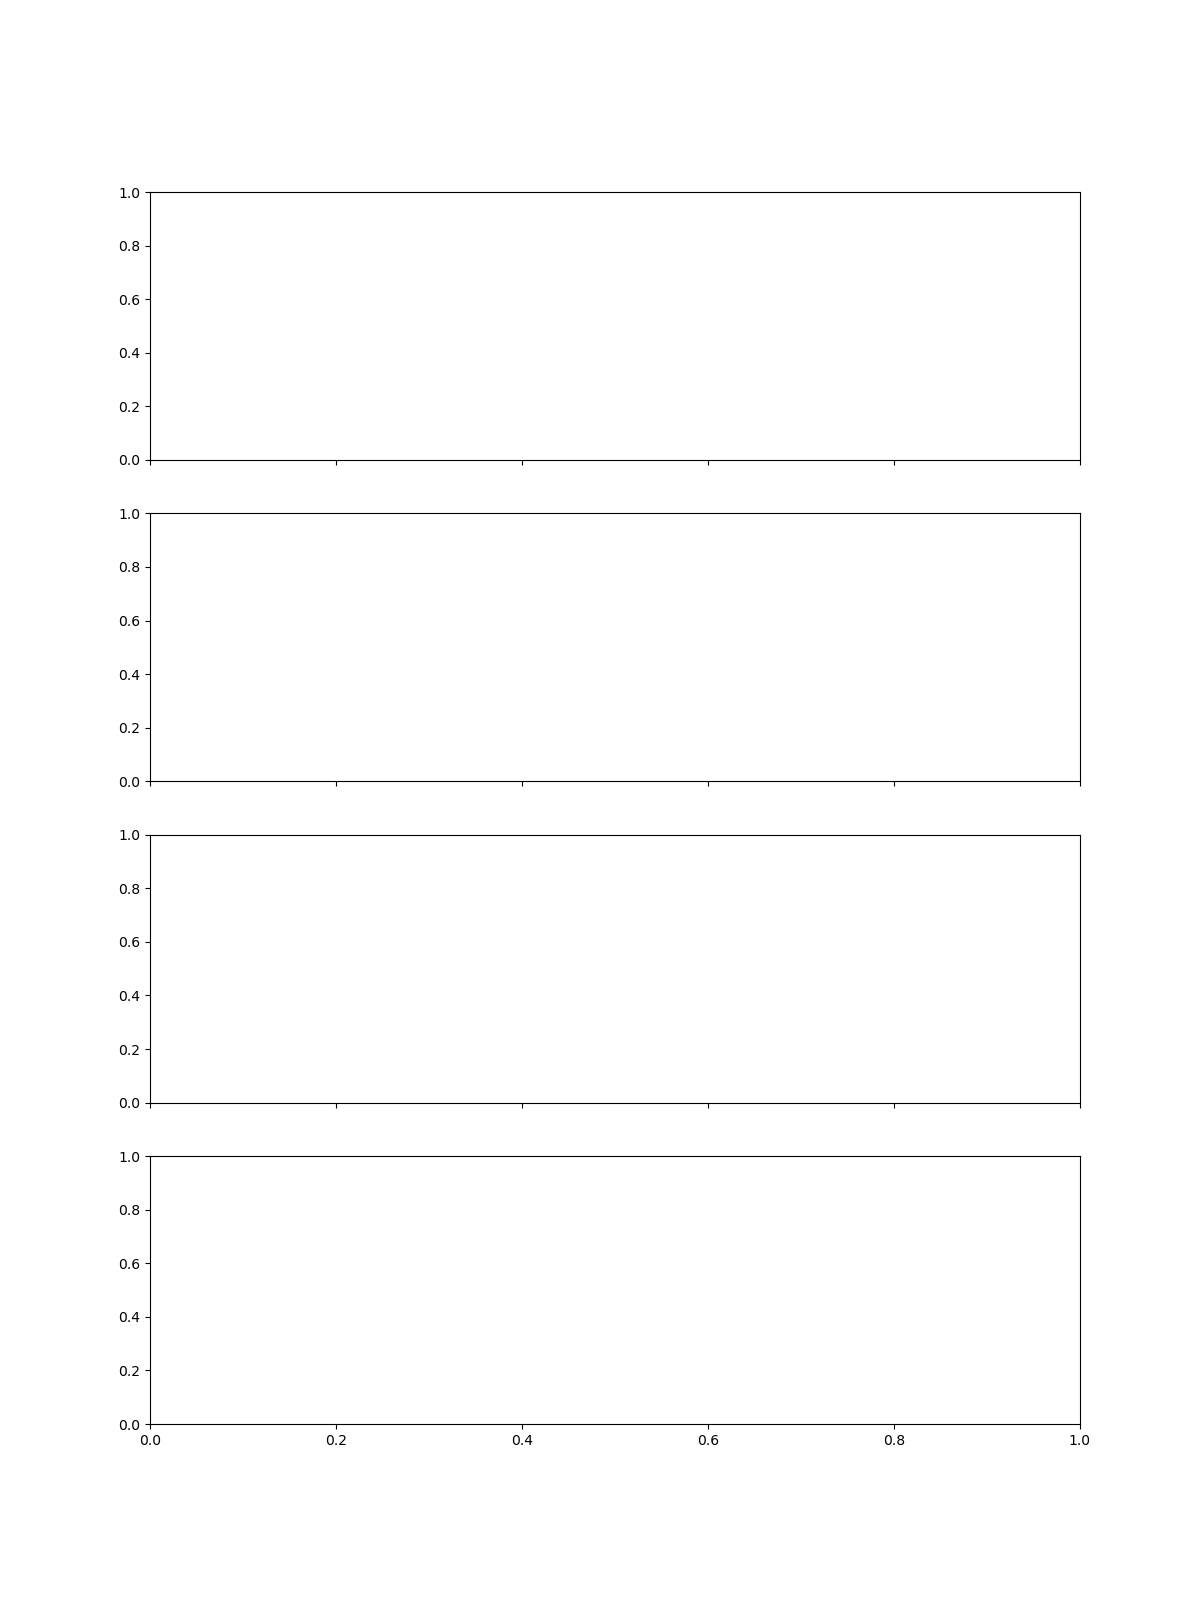

In [3]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from IPython.display import HTML
import os

class BatchProcessingMachine:
    def __init__(self, processing_time, batch_size):
        self.processing_time = processing_time
        self.batch_size = batch_size
        self.batch = []
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, current_time):
        if len(self.batch) == self.batch_size:
            self.busy = True
            self.finish_time = current_time + self.processing_time
            processed_product = self.batch[0]  # Assuming all products in batch are same
            self.event_log.append((processed_product, current_time, self.finish_time, self.batch_size))
            self.batch = []  # Clear batch after processing
            return processed_product
        return None

    def add_to_batch(self, product, current_time):
        self.batch.append(product)
        if len(self.batch) == self.batch_size:
            return self.process(current_time)

    def update(self, current_time):
        if current_time >= self.finish_time:
            self.busy = False
            return True
        return False

class Machine:
    def __init__(self, processing_times, setup_times):
        self.processing_times = processing_times
        self.setup_times = setup_times
        self.current_product = None
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, product, current_time):
        self.busy = True
        setup_time = 0
        if self.current_product is not None:
            setup_time = self.setup_times[self.current_product][product]
        # Update current_product right before new assignment
        self.event_log.append(('setup', current_time, current_time + setup_time, setup_time, product, self.current_product))
        self.current_product = product  # Now update to new product
        start_time = current_time + setup_time
        self.finish_time = start_time + self.processing_times[product]
        self.event_log.append((product, start_time, self.finish_time))
        return self.finish_time
    
    def update(self, current_time):
        if current_time >= self.finish_time:
            self.busy = False
            finished_product = self.current_product
            # Do not reset current_product here; let it change when a new product starts processing
            return finished_product
        return None

    def print_event_log(self):
        for event in self.event_log:
            if event[0] == 'setup':
                print(f"Setup for Product {event[4]} after {event[5]}: from {event[1]} to {event[2]} (Setup time: {event[3]} sec)")
            else:
                print(f"Product {event[0]}: Processed from {event[1]} to {event[2]}")


class ProductionLine:
    def __init__(self, batch_machine_time, machine1_times, machine1_setups, machine2_times, machine2_setups, arrival_rate1, arrival_rate2):
        self.machine0 = BatchProcessingMachine(batch_machine_time, 4)
        self.machine1 = Machine(machine1_times, machine1_setups)
        self.machine2 = Machine(machine2_times, machine2_setups)
        self.arrival_rate1 = arrival_rate1
        self.arrival_rate2 = arrival_rate2
        self.next_arrival1 = 0
        self.next_arrival2 = 0
        self.queue = []
        self.finished_products = [0, 0]
        self.queue_log = []
        self.buffer = []
        self.buffer_log = []  # Log to track buffer status over time

    def add_item(self, product, current_time):
        self.queue.append((product, current_time))
        queue_size_0 = sum(1 for p, _ in self.queue if p == 0)
        queue_size_1 = sum(1 for p, _ in self.queue if p == 1)
        self.queue_log.append(((queue_size_0, queue_size_1), current_time))  # Log queue size per product and time        

    def run_step(self, current_time):
        if current_time >= self.next_arrival1:
            self.queue0.append((0, current_time))
            self.queue_log0.append((len(self.queue0), current_time))
            self.next_arrival1 += self.arrival_rate1

        if current_time >= self.next_arrival2:
            self.queue0.append((1, current_time))
            self.queue_log0.append((len(self.queue0), current_time))
            self.next_arrival2 += self.arrival_rate2

        if self.queue0 and not self.machine0.busy:
            product, _ = self.queue0.pop(0)
            processed_product = self.machine0.add_to_batch(product, current_time)
            if processed_product is not None and not self.machine1.busy:
                self.machine1.process(processed_product, current_time)

        if self.machine0.update(current_time):
            # Process next batch if machine0 just became free and queue is not empty
            while self.queue0 and not self.machine0.busy:
                product, _ = self.queue0.pop(0)
                processed_product = self.machine0.add_to_batch(product, current_time)
                if processed_product is not None:
                    if not self.machine1.busy:
                        self.machine1.process(processed_product, current_time)
                    break

        if self.queue and not self.machine1.busy:
            product, _ = self.queue.pop(0)
            self.machine1.process(product, current_time)

        if not self.machine2.busy and self.buffer:
            next_product = self.buffer.pop(0)
            self.machine2.process(next_product, current_time)
            self.log_buffer_status(current_time)  # Log buffer status after moving item to Machine 2

        if self.machine1.busy and current_time >= self.machine1.finish_time:
            finished_product = self.machine1.update(current_time)
            if finished_product is not None:
                if not self.machine2.busy:
                    self.machine2.process(finished_product, current_time)
                else:
                    self.buffer.append(finished_product)
                    self.log_buffer_status(current_time)  # Log buffer status after adding item

        finished_product = self.machine2.update(current_time)
        if finished_product is not None:
            self.finished_products[finished_product] += 1

        if current_time >= self.next_arrival1:
            self.add_item(0, current_time)
            self.next_arrival1 += self.arrival_rate1

        if current_time >= self.next_arrival2:
            self.add_item(1, current_time)
            self.next_arrival2 += self.arrival_rate2

    def log_buffer_status(self, current_time):
        # Count each product type in the buffer
        buffer_size_0 = sum(1 for p in self.buffer if p == 0)
        buffer_size_1 = sum(1 for p in self.buffer if p == 1)
        # Record current buffer state (counts of each product and current time)
        self.buffer_log.append(((buffer_size_0, buffer_size_1), current_time))


    def print_queue_status(self, current_time):
        queue_status = f"Queue at Time {current_time}: ["
        queue_status += ", ".join(f"Product {prod} (Arrived at {time})" for prod, time in self.queue)
        queue_status += "]"
        print(queue_status)




def animate(i, production_line, gantt_ax, queue0_ax, queue_ax, buffer_ax):
    production_line.run_step(i)

    # Update for Machine0 in Gantt chart
    for event in production_line.machine0.event_log:
        if i >= event[1] and i <= event[2]:
            gantt_ax.broken_barh([(event[1], event[2] - event[1])], (2, 0.8), facecolors=('green' if event[0] == 0 else 'orange'), label=f'Batch Machine - Product {event[0]}')

    # Update queue0 plot
    queue0_times = [time for _, time in production_line.queue_log0]
    queue0_sizes = [size for size, _ in production_line.queue_log0]
    queue0_ax.clear()
    queue0_ax.plot(queue0_times, queue0_sizes, label='Queue Size for Machine 0', color='purple')
    queue0_ax.set_title('Queue Status for Machine 0')
    queue0_ax.set_xlabel('Time')
    queue0_ax.set_ylabel('Queue Size')
    queue0_ax.legend(loc='upper left')
    production_line.run_step(i)
    
    # Plot queue status on the lower subplot
    queue_times = [time for _, time in production_line.queue_log]
    queue_sizes_0 = [size[0] for size, _ in production_line.queue_log]
    queue_sizes_1 = [size[1] for size, _ in production_line.queue_log]
    queue_ax.clear()
    queue_ax.plot(queue_times, queue_sizes_0, label='Queue Size - Product 0', color='blue')
    queue_ax.plot(queue_times, queue_sizes_1, label='Queue Size - Product 1', color='red')
    queue_ax.set_title('Queue Status')
    queue_ax.set_xlabel('Time')
    queue_ax.set_ylabel('Queue Size')
    queue_ax.legend(loc='upper left')

   # Initialize a set to track labels
    used_labels = set()

    # Inside the plotting loop
    for machine_idx, machine in enumerate([production_line.machine1, production_line.machine2]):
        for event in machine.event_log:
            start, end = event[1], event[2]
            color = 'blue' if event[0] == 0 else 'red'
            label = None  # Default to no label
            if event[0] == 'setup':
                color = 'grey'
                label_text = f'Machine {machine_idx + 1} Setup'
                if label_text not in used_labels and i == 0:
                    label = label_text
                    used_labels.add(label_text)
            else:
                label_text = f'Machine {machine_idx + 1} - Product {event[0]}'
                if label_text not in used_labels and i == 0:
                    label = label_text
                    used_labels.add(label_text)
            gantt_ax.broken_barh([(start, end - start)], (machine_idx, 0.8), facecolors=color, label=label)

    # Setting static elements (will not clear on every frame)
    if i == 0:
        handles, labels = gantt_ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        gantt_ax.legend(by_label.values(), by_label.keys())
        gantt_ax.set_yticks([0.4, 1.4])
        gantt_ax.set_yticklabels(['Machine 1', 'Machine 2'])
        gantt_ax.set_title('Machine Processing Times')
        gantt_ax.set_xlabel('Time')
        gantt_ax.set_ylabel('Machine')
        gantt_ax.legend(loc='upper left')
    
    # Update the buffer plot
    buffer_times = [time for _, time in production_line.buffer_log]
    buffer_sizes_0 = [size[0] for size, _ in production_line.buffer_log]
    buffer_sizes_1 = [size[1] for size, _ in production_line.buffer_log]
    buffer_ax.clear()
    buffer_ax.plot(buffer_times, buffer_sizes_0, label='Buffer Size - Product 0', color='green')
    buffer_ax.plot(buffer_times, buffer_sizes_1, label='Buffer Size - Product 1', color='orange')
    buffer_ax.set_title('Buffer Status')
    buffer_ax.set_xlabel('Time')
    buffer_ax.set_ylabel('Buffer Size')
    buffer_ax.legend(loc='upper left')

    plt.tight_layout()
    plt.suptitle(f'Elapsed Time: {i} units')


fig, (gantt_ax, queue0_ax, queue_ax, buffer_ax) = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
# Create ProductionLine instance
production_line = ProductionLine(10, {0: 3, 1: 4}, {None: {0: 5, 1: 3}, 0: {0: 0, 1: 10}, 1: {0: 5, 1: 0}},
                                 {0: 10, 1: 12}, {None: {0: 0, 1: 0}, 0: {0: 0, 1: 2}, 1: {0: 3, 1: 0}}, 20, 10)

ani = FuncAnimation(fig, animate, frames=np.arange(0, 200, 1), fargs=(production_line, gantt_ax, queue0_ax, queue_ax, buffer_ax), interval=100, repeat=False)
plt.show()


In [ ]:
#frames=np.arange(0, 20, 1): This sets the frames to be integers from 0 to 19. The function animate is called with each of these integers (i) sequentially.
#fargs=(production_line, gantt_ax, queue_ax): These are additional arguments passed to the animate function.
#interval=100: This sets the interval between frames to 100 milliseconds.

In [ ]:
#Next steps
# 1) Introduce a demand forecast into the state space and reward it for meeting future excess demand
# 2) See if it can switch demand patterns quickly 
# 3) Q-learning implementaion to achive the same result
# 4) Write a LP program of this